<a href="https://colab.research.google.com/github/luisGomezOjeda/repositorio_aprendizaje_automatico1/blob/main/TP5_AA1_clasificaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 AA1 Clasificación

**Escriba aquí su nombre completo**

## Indicaciones básicas

0) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

1) Cada uno debe completar las consignas indicadas en este notebook.

2)
3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio / parcial

7) Revise las fecha límite de entrega de este trabajo

# ENTREGA

**LEA LAS INDICACIONES DE ENTREGA EN EL FORO DE LA TAREA**

#**Tarea: Entrenamiento y evaluación de clasificadores**  

**Objetivo**: Aplicar un modelo de clasificación a un dataset de su elección, procesar dicho dataset para poder usarlo para entrenamiento, indicar y compartir todos los recursos utilizados, evaluar su rendimiento.

---

# **Instrucciones**:

#1. **Selección del Dataset**  
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets?Task=Classification&skip=0&take=10&sort=desc&orderBy=Relevance&search=
   - Requisitos:  
     - Debe tener al menos 4 variables.
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.  



## Resolución:

In [1]:
!wget https://archive.ics.uci.edu/static/public/45/heart+disease.zip

--2026-06-26 15:54:03--  https://archive.ics.uci.edu/static/public/45/heart+disease.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘heart+disease.zip’

heart+disease.zip       [  <=>               ] 125.87K   326KB/s    in 0.4s    

2026-06-26 15:54:04 (326 KB/s) - ‘heart+disease.zip’ saved [128894]



In [2]:
!unzip heart+disease.zip

Archive:  heart+disease.zip
  inflating: Index                   
  inflating: WARNING                 
  inflating: ask-detrano             
  inflating: bak                     
  inflating: cleve.mod               
  inflating: cleveland.data          
   creating: costs/
  inflating: costs/Index             
  inflating: costs/heart-disease.README  
  inflating: costs/heart-disease.cost  
  inflating: costs/heart-disease.delay  
  inflating: costs/heart-disease.expense  
  inflating: costs/heart-disease.group  
  inflating: heart-disease.names     
  inflating: hungarian.data          
  inflating: long-beach-va.data      
  inflating: new.data                
  inflating: processed.cleveland.data  
  inflating: processed.hungarian.data  
  inflating: processed.switzerland.data  
  inflating: processed.va.data       
  inflating: reprocessed.hungarian.data  
  inflating: switzerland.data        


In [3]:
import os
import pandas as pd

columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]
df = pd.read_csv('processed.cleveland.data',header=None,names=columns)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Seleccione el dataset de Heart Disease :
Este conjunto es una convinación de 4 bases de datos con las 14 variables comunes en dichas bases de datos. Contiene datos acerca los resultados de estudios cardiologicos de diferentesde pacientes clasificados con dos tipos de diagnosticos :
- 0 : Paciente que no padese cardiopatía
- 1 : paciente que padece cardiopatía


## 2. **Análisis exploratorio (previo al modelado)**  
   - Describan las variables (media, distribución, outliers).  
   - Visualizen:  
     - Histogramas o boxplots para ver distribuciones.  
     - Gráficos de dispersión (scatterplots) entre features y target.  
   - Describan si observan o no relaciones entre algunas variables.  


## Resolución:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


Este conjunto de datos no presenta valores nulos, tiene 13 variables de tipo entera y unicamente una de tipo flotante

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


Comparando la desviación estándar vs la media vs la mediana de todas las variables, noto que hay una variación considerable en todas, y donde hay diferencias negativas entre la media de las variables y la mediana de las mismas, lo que indica que pueden existir valores atípicamente bajos en las variables o una minoria en variables categoricas bajas.

La separación de variables numericas y categoricas es la siguente :

In [6]:
numericas = [
    'age', 'trestbps', 'chol',
    'thalach', 'oldpeak'
]

categoricas = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'thal', 'target','ca'
]

nombres_descriptivos = [
    "Edad",
    "Sexo",
    "Tipo de dolor de pecho",
    "Presión arterial en reposo",
    "Colesterol sérico",
    "Glucosa en ayunas",
    "Resultado del electrocardiograma en reposo",
    "Frecuencia cardíaca máxima alcanzada",
    "Angina inducida por ejercicio",
    "Depresión del segmento ST",
    "Pendiente del segmento ST",
    "Número de vasos principales afectados",
    "Resultado de la prueba de talasemia",
    "Presencia de enfermedad cardíaca"
]

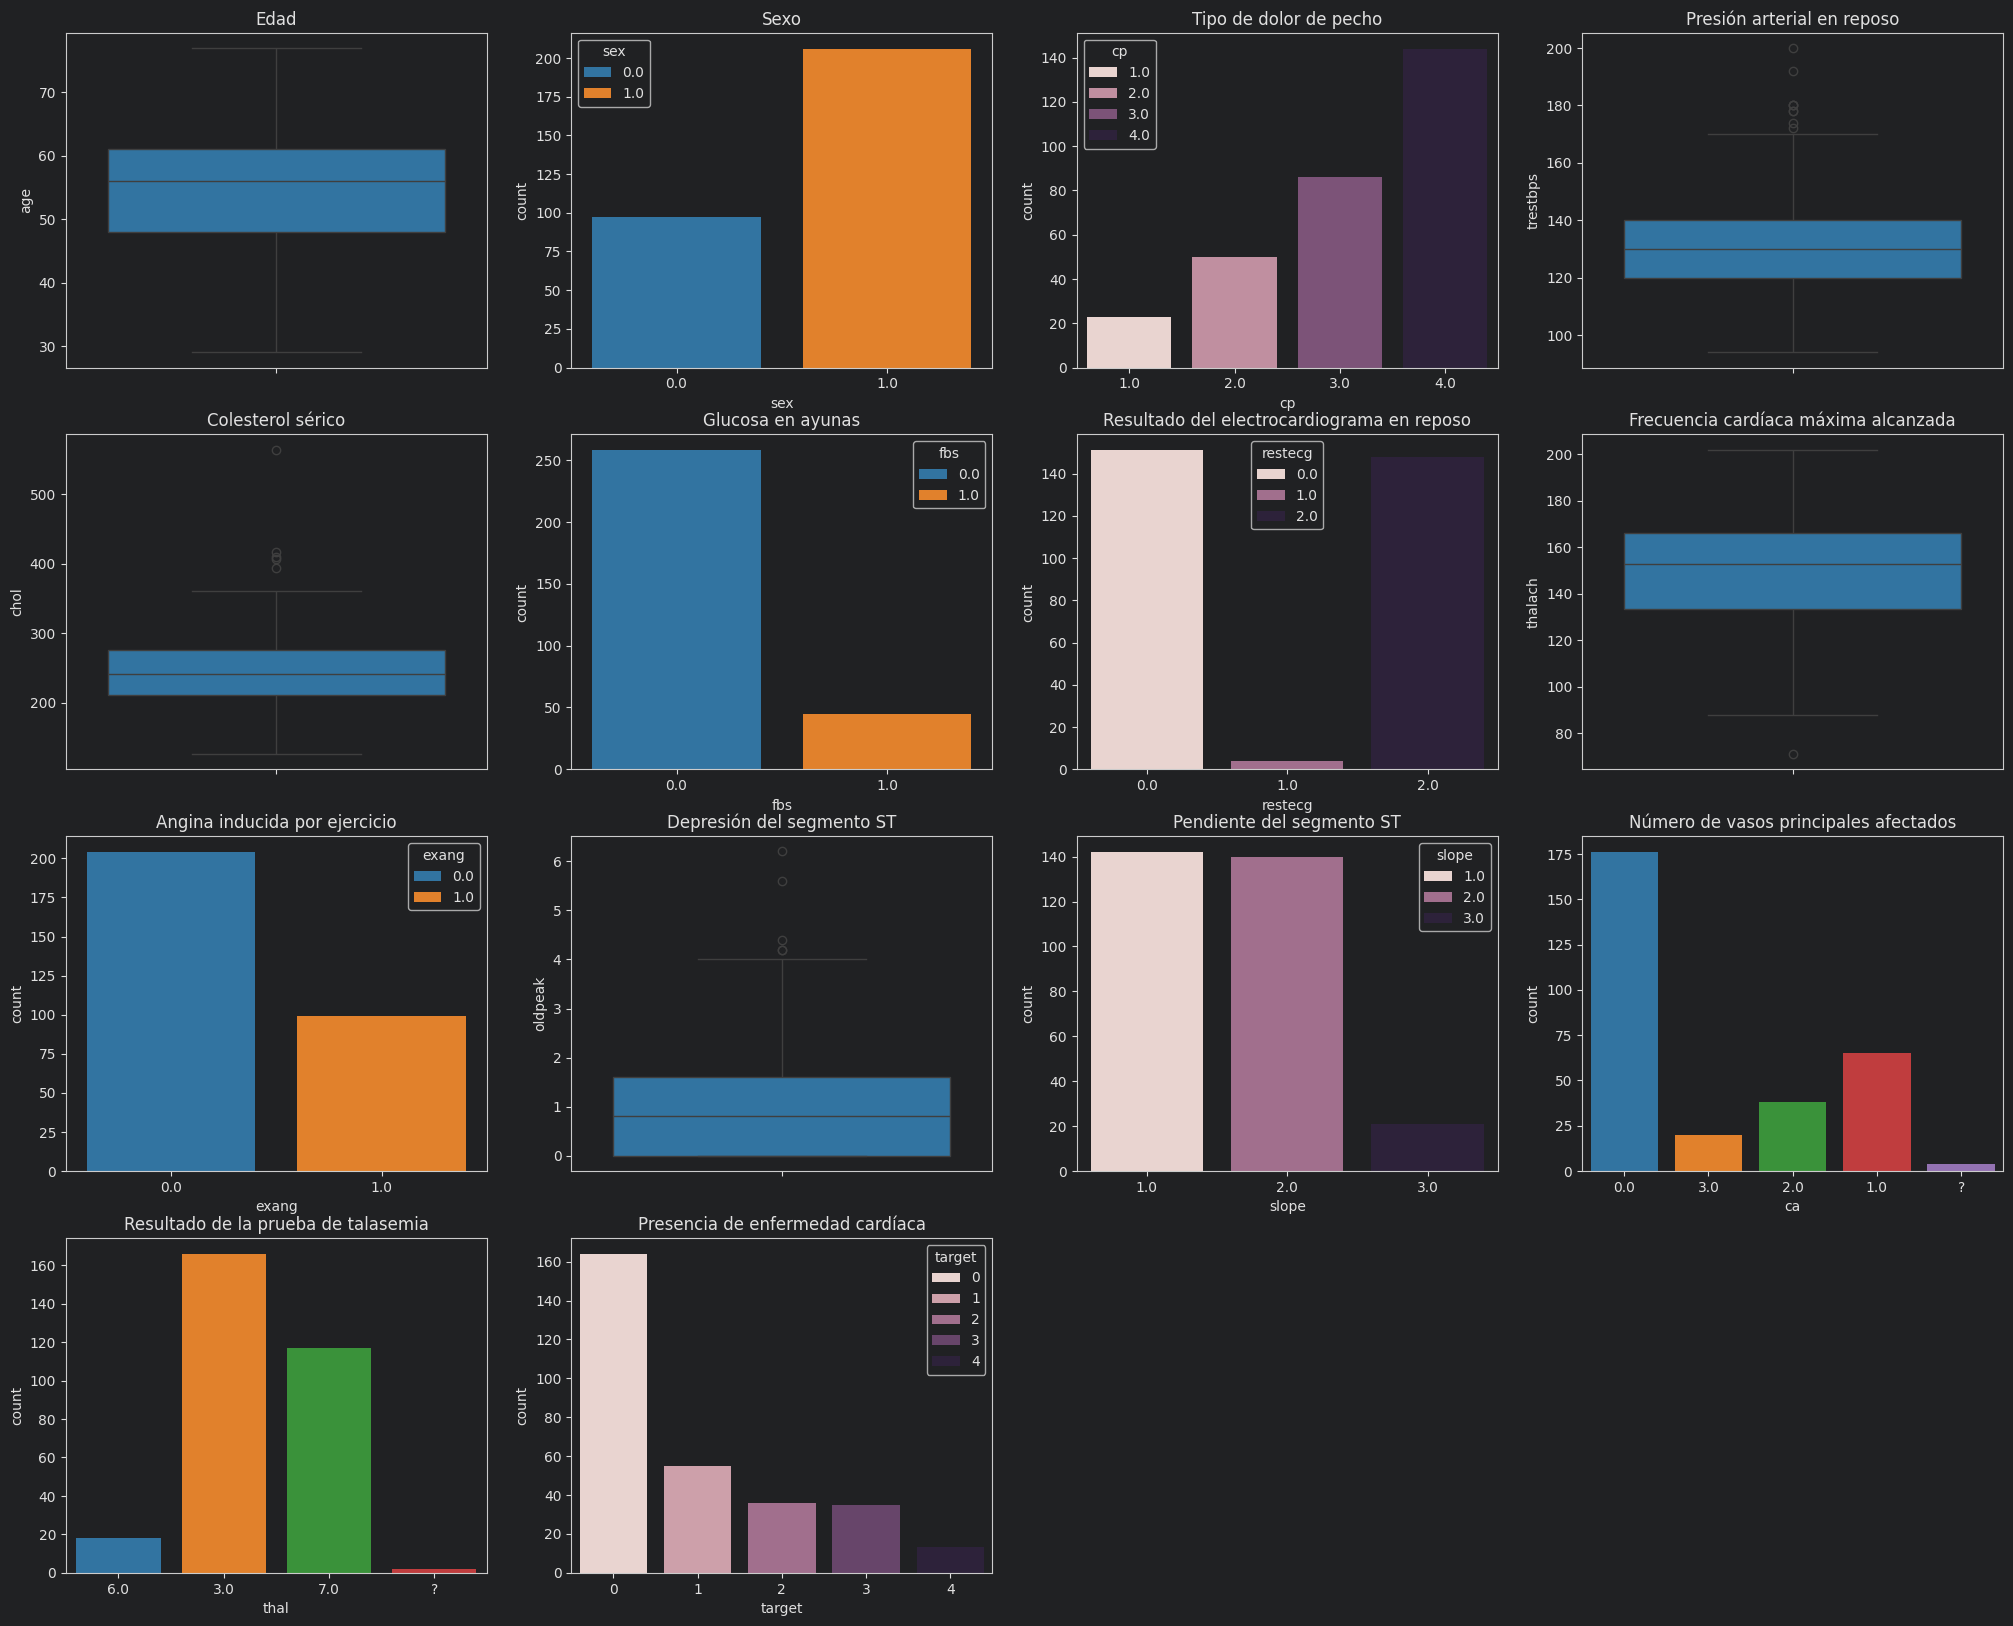

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
dark = {
    "axes.facecolor": "#202123",
    "figure.facecolor": "#202123",
    "axes.edgecolor": "#CCCCCC",
    "axes.labelcolor": "#E0E0E0",
    "xtick.color": "#E0E0E0",
    "ytick.color": "#E0E0E0",
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "text.color": "#E0E0E0",
    "lines.color": "#10A37F",
    "patch.edgecolor": "#E0E0E0",
    "axes.titleweight": "bold",
    "axes.titlesize": 20,
    "axes.labelsize": 18
}

sns.set_style(dark)


fig,ax= plt.subplots(4,4,figsize=(25,20))
ax = ax.flatten()

for i in range(len(ax)) :
    if i < len(df.columns) :
        name_col = df.iloc[:,i].name
        ax[i].set_title(nombres_descriptivos[i])
        if name_col in numericas :
            sns.boxplot(df,y=name_col ,ax=ax[i])
        elif name_col in categoricas :
            sns.countplot(df,x=name_col,ax=ax[i],hue=name_col)
            ax[i].set_title(nombres_descriptivos[i])
    else :
        fig.delaxes(ax[i])

plt.show()
display(df.columns)

In [8]:
df.loc[df['target'] > 0 ,'target'] = 1


from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency

X = df.drop(columns=['target','thal','ca']).copy()
y = df['target'].copy()
indices_cat = categoricas
indices_cat.remove('target')
indices_cat.remove('thal')
indices_cat.remove('ca')
indices_cat = df.columns.get_indexer(indices_cat)

score = mutual_info_classif(X,y,discrete_features=indices_cat)

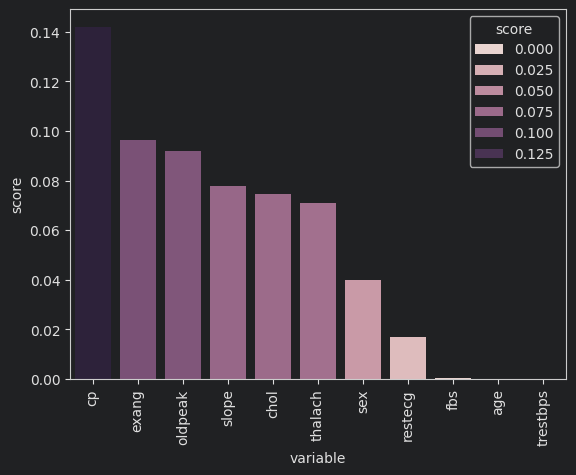

In [9]:
df_ranking = pd.DataFrame({'variable' : X.columns,'score': score}).sort_values(by='score',ascending=False)

sns.barplot(data=df_ranking,x='variable',y='score',hue='score')
plt.xticks(rotation=90)
plt.show()

**Demográficos**

* **`age`**: Edad.
* **`sex`**: Sexo (1 = Hombre, 0 = Mujer).

**Sintoma**
* **`cp`**: Tipo de dolor de pecho (Categórica Nominal: Angina típica, atípica, no anginoso, o asintomático).

**Mediciones en Reposo**
* **`trestbps`**: Presión arterial.
* **`chol`**: Colesterol total.
* **`fbs`**: Glucosa alta (>120 mg/dl: 1 = Sí, 0 = No).
* **`restecg`**: Electrocardiograma (0 = Normal, 1-2 = Anomalías).

**Mediciones en Esfuerzo**

* **`thalach`**: Frecuencia cardíaca máxima alcanzada.
* **`exang`**: Angina/Dolor inducido por ejercicio (1 = Sí, 0 = No).
* **`oldpeak`**: Depresión del segmento ST (indicador de isquemia).
* **`slope`**: Pendiente del segmento ST.

**Gravedad y Diagnóstico**

* **`ca`**: Cantidad de vasos principales obstruidos (0 a 3).
* **`thal`**: Flujo sanguíneo al tejido (Normal, defecto fijo o reversible).
* **`target`**: Enfermedad cardíaca (1 = Presencia, 0 = Ausencia).

## 3. **Preprocesamiento**  
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).  
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Otros pasos que crea conveniente para pre-procesar el dataset (mencione y explique)

Detalla las caracteristicas del dataset como nro de variables, nro de filas o instancias, si el problema es clasificacion binaria o multiclase, y otras características que crea conveniente.

Realice la división de datos (entrenamiento / testeo / CV según corresponda)

## Resolución:

Decidí excluir las variables ca (número de vasos principales observados mediante fluoroscopia) y thal (resultado del estudio de perfusión miocárdica o talasemia, según la codificación del dataset), ya que ambas provienen de estudios cardiológicos especializados que generalmente se realizan en etapas avanzadas del proceso diagnóstico para confirmar o evaluar con mayor precisión la presencia de enfermedad coronaria. En cambio, las demás variables corresponden a información clínica y estudios de rutina que suelen estar disponibles durante la evaluación inicial del paciente, como la edad, la presión arterial, el colesterol, el electrocardiograma en reposo y la presencia de angina inducida por ejercicio. De esta forma, el modelo busca predecir el riesgo de enfermedad cardíaca utilizando únicamente información accesible antes de realizar estudios diagnósticos de mayor complejidad, lo que lo hace más útil como herramienta de apoyo para la detección temprana.

In [10]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

X = df.drop(columns=['target','thal','ca'],axis=1).copy()
y = df['target'].copy()


onehot = OneHotEncoder(sparse_output=False)
datos_categoricos = onehot.fit_transform(X[['cp','restecg']])
nombres_categoricos_onehot = onehot.get_feature_names_out(['cp','restecg'])
nombres_categoricos_onehot
X.drop(columns=['cp','restecg'],axis=1)
X[nombres_categoricos_onehot] = datos_categoricos


X[numericas] = StandardScaler().fit_transform(X[numericas])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Antes del entrenamiento de los modelos se aplicó un preprocesamiento mínimo de los datos. Las variables categóricas nominales fueron transformadas mediante One-Hot Encoding, convirtiendo cada categoría en una variable binaria para que pudieran ser interpretadas correctamente por los algoritmos de aprendizaje automático. Por otro lado, las variables continuas fueron estandarizadas utilizando StandardScaler, de manera que todas presentaran una media de 0 y una desviación estándar de 1. Esta estandarización evita que las diferencias de escala entre las variables influyan en el proceso de entrenamiento, especialmente en modelos sensibles a la magnitud de los atributos, como la regresión logística.

In [11]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,cp_1.0,cp_2.0,cp_3.0,cp_4.0,restecg_0.0,restecg_1.0,restecg_2.0
0,0.948726,1.0,1.0,0.757525,-0.264900,1.0,2.0,0.017197,0.0,1.087338,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.392002,1.0,4.0,1.611220,0.760415,0.0,2.0,-1.821905,1.0,0.397182,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1.392002,1.0,4.0,-0.665300,-0.342283,0.0,2.0,-0.902354,1.0,1.346147,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-1.932564,1.0,3.0,-0.096170,0.063974,0.0,0.0,1.637359,0.0,2.122573,3.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,-1.489288,0.0,2.0,-0.096170,-0.825922,0.0,2.0,0.980537,0.0,0.310912,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,1.0,1.0,-1.234430,0.334813,0.0,0.0,-0.770990,0.0,0.138373,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
299,1.502821,1.0,4.0,0.700612,-1.038723,1.0,0.0,-0.376896,0.0,2.036303,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
300,0.283813,1.0,4.0,-0.096170,-2.238149,0.0,0.0,-1.515388,1.0,0.138373,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
301,0.283813,0.0,2.0,-0.096170,-0.206864,0.0,2.0,1.068113,0.0,-0.896862,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0





## 4. **Clasificación con logistic regression**  
   

En este apartado entrenará un clasificador con la librería sklearn usando logistic regresion.

### 4.1 Entrenamiento y evaluación

In [12]:
from sklearn.linear_model import LogisticRegression


regresion_logistica1 = LogisticRegression(max_iter=1000,verbose=1,C=1,class_weight='balanced')
regresion_logistica1.fit(X_train, y_train)

regresion_logistica2 = LogisticRegression(max_iter=1000,verbose=1,C=0.1)
regresion_logistica2.fit(X_train, y_train)

display(f'Número de iteraciones : {regresion_logistica1.n_iter_[0]}')
display(f'Número de iteraciones : {regresion_logistica2.n_iter_[0]}')
#y_pred = regresion_logistica1.predict(X_test)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


'Número de iteraciones : 33'

'Número de iteraciones : 16'

### 4.2 Métricas de evaluación

Muestre el desempeño en el conjunto de datos de entrenamiento y testeo.
Mencione las métricas utilizadas. No se olvide de mostrar la matriz de confusión.
Explique los resultados obtenidos.

'El f1 score del conjunto de entrenamiento es : 81.69%'

'El f1 score del conjunto de testeo es : 78.79%'

'La sensibilidad del entrenamiento es : 81.31%'

'La sensibilidad del del conjunto de testeo es : 81.25%'

'La precisión del entrenamiento es : 82.08%'

'La precisión del del conjunto de testeo es : 76.47%'

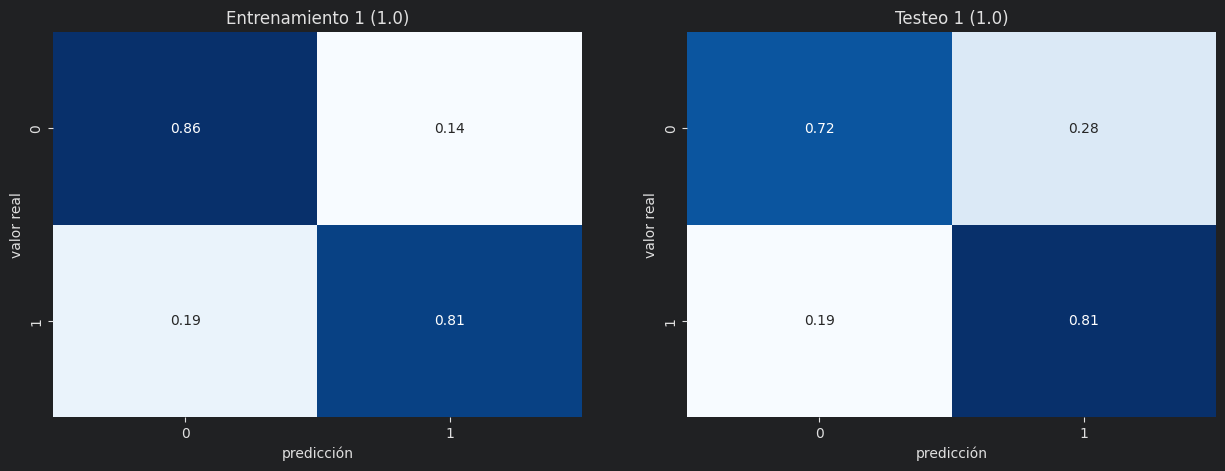

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score,f1_score

y_pred_train1 = regresion_logistica1.predict(X_train)
y_pred_test1 = regresion_logistica1.predict(X_test)


y_pred_train2 = regresion_logistica2.predict(X_train)
y_pred_test2 = regresion_logistica2.predict(X_test)


matrix1 = confusion_matrix(y_train, y_pred_train1,normalize='true')
matrix2 = confusion_matrix(y_test, y_pred_test1,normalize='true')


fig_1,ax_1 = plt.subplots(1,2,figsize=(15,5))
sns.heatmap(matrix1, annot=True, cbar=False,cmap='Blues',ax=ax_1[0])
sns.heatmap(matrix2, annot=True, cbar=False,cmap='Blues',ax=ax_1[1])
ax_1[0].set_title('Entrenamiento 1 (1.0)')
ax_1[1].set_title('Testeo 1 (1.0)')

ax_1[0].set_xlabel('predicción')
ax_1[0].set_ylabel('valor real')
ax_1[1].set_xlabel('predicción')
ax_1[1].set_ylabel('valor real')

matrix1 = confusion_matrix(y_train, y_pred_train2,normalize='true')
matrix2 = confusion_matrix(y_test, y_pred_test2,normalize='true')

fig_1.show()

f1_score_train1 = f1_score(y_train, y_pred_train1)
f1_score_test1 = f1_score(y_test, y_pred_test1)

recall_score_train1 = recall_score(y_train, y_pred_train1)
recall_score_test1 = recall_score(y_test, y_pred_test1)

precision_score_train1 = precision_score(y_train, y_pred_train1)
precision_score_test1 = precision_score(y_test, y_pred_test1)


display(f'El f1 score del conjunto de entrenamiento es : {round(f1_score_train1 * 100,2)}%')
display(f'El f1 score del conjunto de testeo es : {round(f1_score_test1 * 100,2)}%')

display(f'La sensibilidad del entrenamiento es : {round(recall_score_train1 * 100,2)}%')
display(f'La sensibilidad del del conjunto de testeo es : {round(recall_score_test1 * 100,2)}%')

display(f'La precisión del entrenamiento es : {round(precision_score_train1 * 100,2)}%')
display(f'La precisión del del conjunto de testeo es : {round(precision_score_test1 * 100,2)}%')



'El f1 score del conjunto de entrenamiento es : 77.0%'

'El f1 score del conjunto de testeo es : 73.33%'

'La sensibilidad del entrenamiento es : 71.96%'

'La sensibilidad del del conjunto de testeo es : 68.75%'

'La precisión del entrenamiento es : 82.8%'

'La precisión del del conjunto de testeo es : 78.57%'

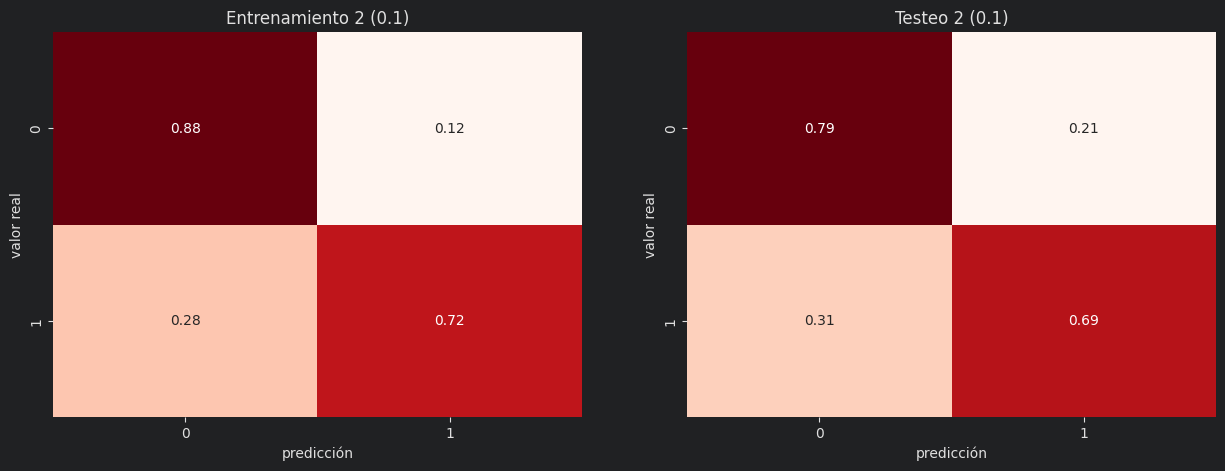

In [14]:
fig_2,ax_2 = plt.subplots(1,2,figsize=(15,5))
sns.heatmap(matrix1, annot=True, cbar=False,cmap='Reds',ax=ax_2[0])
sns.heatmap(matrix2, annot=True, cbar=False,cmap='Reds',ax=ax_2[1])
ax_2[0].set_title('Entrenamiento 2 (0.1)')
ax_2[1].set_title('Testeo 2 (0.1)')

ax_2[0].set_xlabel('predicción')
ax_2[0].set_ylabel('valor real')
ax_2[1].set_xlabel('predicción')
ax_2[1].set_ylabel('valor real')

f1_score_train2_ = f1_score(y_train, y_pred_train2)
f1_score_test2 = f1_score(y_test, y_pred_test2)

recall_score_train2_ = recall_score(y_train, y_pred_train2)
recall_score_test2 = recall_score(y_test, y_pred_test2)

precision_score_train2_ = precision_score(y_train, y_pred_train2)
precision_score_test2 = precision_score(y_test, y_pred_test2)


fig_2.show()

display(f'El f1 score del conjunto de entrenamiento es : {round(f1_score_train2_ * 100,2)}%')
display(f'El f1 score del conjunto de testeo es : {round(f1_score_test2 * 100,2)}%')

display(f'La sensibilidad del entrenamiento es : {round(recall_score_train2_ * 100,2)}%')
display(f'La sensibilidad del del conjunto de testeo es : {round(recall_score_test2 * 100,2)}%')

display(f'La precisión del entrenamiento es : {round(precision_score_train2_ * 100,2)}%')
display(f'La precisión del del conjunto de testeo es : {round(precision_score_test2 * 100,2)}%')



el primer modelo presentan un leve nivel de sobreajuste, ya que su desempeño en el conjunto de entrenamiento es ligeramente superior al obtenido en el conjunto de prueba. Sin embargo, considerando las métricas de evaluación en su conjunto y poniendo especial énfasis en la capacidad del modelo para identificar correctamente la mayor cantidad de casos positivos (recall), se selecciona el primer modelo, correspondiente al valor de regularización C = [1], por ofrecer el mejor equilibrio entre capacidad de generalización y rendimiento predictivo.

## 5- **Otro clasificador**

### 5.1 Elija otro modelo para entrenar un clasificador

Elija alguno de los modelos vistos: kNN, SVM o MLP para entrenar un clasificador usando los parámetros por defecto de sklearn.

Justifique su elección.

### 5.2 Entrenamiento del modelo.

El algoritmo K-Nearest Neighbors (KNN) es un método de aprendizaje supervisado utilizado para tareas de clasificación y regresión. En el caso de la clasificación, cuando se presenta una nueva observación, el algoritmo calcula la distancia entre esta y todas las instancias del conjunto de entrenamiento. Luego, identifica los k vecinos más cercanos y asigna a la nueva observación la clase que predomina entre esos vecinos mediante una votación por mayoría.

In [15]:
from sklearn.neighbors import KNeighborsClassifier


list_precision_train = []
list_precision_test = []

for k in range(3,11,2) :
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred_train_knn = knn.predict(X_train)
    y_pred_test_knn = knn.predict(X_test)

    f1_score_train_knn = f1_score(y_train, y_pred_train_knn)
    f1_score_test_knn = f1_score(y_test, y_pred_test_knn)
    sennsibilidad_train_knn = recall_score(y_train, y_pred_train_knn)
    sennsibilidad_test_knn = recall_score(y_test, y_pred_test_knn)
    presicion_train_knn = precision_score(y_train, y_pred_train_knn)
    presicion_test_knn = precision_score(y_test, y_pred_test_knn)
    list_precision_train.append({'k_value': k,'precisión' : presicion_train_knn,'sensibilidad' : sennsibilidad_train_knn, 'f1_score': f1_score_train_knn})

    list_precision_test.append({'k_value' : k,'precisión' : presicion_test_knn,'sensibilidad' : sennsibilidad_test_knn,'f1_score' : f1_score_test_knn})

df_knn_train = pd.DataFrame(list_precision_train).sort_values(by='k_value',ascending=False)
df_knn_test = pd.DataFrame(list_precision_test).sort_values(by='k_value')
display(df_knn_train)
display(df_knn_test)

,k_value,precisión,sensibilidad,f1_score
3,9,0.793814,0.719626,0.754902
2,7,0.818182,0.757009,0.786408
1,5,0.785047,0.785047,0.785047
0,3,0.839623,0.831776,0.835681


,k_value,precisión,sensibilidad,f1_score
0,3,0.757576,0.78125,0.769231
1,5,0.800000,0.75000,0.774194
2,7,0.806452,0.78125,0.793651
3,9,0.870968,0.84375,0.857143


In [16]:
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = "plotly_dark"

hovertemplate=(
            "<b>Sensibilidad:</b> %{x:.2f}<br>"
            "<b>Precisión:</b> %{y:.2f}<br>"
            "<b>valor de k:</b> %{customdata:.0f}"
            "<extra></extra>" # Borra el cuadro lateral con el nombre de la serie
)

fig = go.Figure(data=[go.Scatter(x=df_knn_train['sensibilidad'],mode='lines+markers',y=df_knn_train['precisión'],hovertemplate=hovertemplate,customdata=df_knn_train['k_value'],name='entrenamiento'),go.Scatter(x=df_knn_test['sensibilidad'],mode='lines+markers',y=df_knn_test['precisión'],hovertemplate=hovertemplate,customdata=df_knn_test['k_value'],name='testeo')])

fig.update_layout(
    xaxis_title='sensibilidad',
    yaxis_title='precisión',
)

fig.show()

In [17]:
hovertemplate=(
            "<b>Sensibilidad:</b> %{x:.2f}<br>"
            "<b>Precisión:</b> %{y:.2f}<br>"
            "<b>f1-score</b> %{customdata:.2f}"
            "<extra></extra>" # Borra el cuadro lateral con el nombre de la serie
)

fig2 = go.Figure(data=[go.Scatter(x=df_knn_test['k_value'],y=df_knn_test['f1_score'],mode='lines+markers',hovertemplate=hovertemplate,name='f1 del testeo',customdata=df_knn_test['f1_score'])])

fig2.update_layout(
    xaxis_title='valor de k',
    yaxis_title='f1 score',
)

fig2.show()

### 5.3 Evaluación del desempeño

In [18]:
df_knn_test.loc[df_knn_test['k_value'] == 9]

,k_value,precisión,sensibilidad,f1_score
3,9,0.870968,0.84375,0.857143


## 6  Tuneo de hiperparámetros

En esta sección debe modificar probar cómo la modificación de un hiperparámetro del modelo elegido en punto 5) afecta en los resultados.

Justifique y realice el experimento en esta sección.

## 6- Conclusiones

Fundamente, justifique con sus palabras.

Al comparar el mejor modelo de K-Nearest Neighbors (KNN) con el mejor modelo de Regresión Logística, utilizando las métricas obtenidas sobre el conjunto de prueba, se observa que KNN alcanza un recall (sensibilidad) de un 3% superior, una precisión (precision) un 2% superior y un F1-score un 7% superior. Estos resultados indican que KNN logra identificar una mayor proporción de casos positivos sin sacrificar significativamente la precisión de sus predicciones. En consecuencia, para este conjunto de datos, KNN presenta un mejor desempeño global que la Regresión Logística, por lo que se selecciona como el modelo más adecuado para el problema.